In [1]:
import pandas as pd
import numpy as np

# 1. Cargamos el archivo de metadatos directamente desde la pestaña 'Samples' del Excel original
df_samples = pd.read_excel('ANALYSIS_INTEGRATION.xlsx', sheet_name='Samples')

# 2. Cargamos los datos de expresión (RNA) y epigenética desde sus respectivas pestañas.
# Dado que los pacientes se encuentran en las columnas, establecemos los nombres de genes/marcas como índice (index_col=0) y aplicamos ".T" para transponer las matrices. De esta forma, las filas serán los pacientes.
df_rna = pd.read_excel('ANALYSIS_INTEGRATION.xlsx', sheet_name='RNA', index_col=0).T
df_epig = pd.read_excel('ANALYSIS_INTEGRATION.xlsx', sheet_name='Epig', index_col=0).T

# 3. Cargamos los datos de variantes estructurales y mutaciones (CNV y SNV)
df_cnv = pd.read_excel('ANALYSIS_INTEGRATION.xlsx', sheet_name='CNV')
df_snv = pd.read_excel('ANALYSIS_INTEGRATION.xlsx', sheet_name='SNV')

# 4. Comprobamos las dimensiones para verificar la correcta lectura y transposición de los datos
print("¡Datos cargados con éxito directamente desde el Excel!\n")
print(f"Dimensiones de RNA: {df_rna.shape[0]} pacientes y {df_rna.shape[1]} genes medidos.")
print(f"Dimensiones de Epigenética: {df_epig.shape[0]} pacientes y {df_epig.shape[1]} marcas medidas.")
print("\nVista previa de los datos de RNA transpuestos (pacientes en filas):")
display(df_rna.head(3))

¡Datos cargados con éxito directamente desde el Excel!

Dimensiones de RNA: 10 pacientes y 12 genes medidos.
Dimensiones de Epigenética: 10 pacientes y 74 marcas medidas.

Vista previa de los datos de RNA transpuestos (pacientes en filas):


gene \ sample,TP53,ATM,FBXW7,NOTCH1,NFKBIE,REEP5,BRCA1,KRAS,MYC,CDKN2A,EGFR,PTEN
P1,520,430,300,380,280,610,500,420,360,260,390,450
P2,510,450,290,370,300,590,480,430,340,270,410,460
P3,120,160,100,600,90,250,200,700,900,80,800,150


In [2]:
# PROCESAMIENTO DE DATOS SNV (Single Nucleotide Variants)
# Transformamos el formato largo a una matriz donde las filas son muestras y columnas genes.
print("Transformando los datos de SNV...")

df_snv_matrix = pd.crosstab(df_snv['Sample'], df_snv['Gene'])

Transformando los datos de SNV...


KeyError: 'Sample'

In [3]:
# ERROR DETECTADO: Las columnas se llaman 'sample' y 'gene' en minúscula, no en mayúscula. Lo corregimos:

df_snv_matrix = pd.crosstab(df_snv['sample'], df_snv['gene'])

# Convertimos cualquier número mayor que 0 en un 1 (presencia de mutación) y el resto en 0
df_snv_procesado = (df_snv_matrix > 0).astype(int)

print(f"Dimensiones de SNV procesado: {df_snv_procesado.shape[0]} pacientes y {df_snv_procesado.shape[1]} genes con mutaciones.")
print("\nVista previa de la tabla SNV corregida (1 = mutado, 0 = no mutado):")
display(df_snv_procesado.head(3))

Dimensiones de SNV procesado: 8 pacientes y 11 genes con mutaciones.

Vista previa de la tabla SNV corregida (1 = mutado, 0 = no mutado):


gene,ATM,BIRC3,EGR2,FBXW7,KLHL6,MYD88,NFKBIE,NOTCH1,REEP5,SLC7A8,TP53
sample,,,,,,,,,,,
P1,0,0,0,0,0,0,1,0,1,0,1
P2,0,0,0,1,0,0,1,1,0,0,0
P3,1,0,0,1,1,0,0,1,0,0,1


In [4]:
from sklearn.preprocessing import StandardScaler

# PROCESAMIENTO DE CNV
print("Transformando los datos de CNV...")
# Creamos identificador único de región y pivotamos
df_cnv['region'] = 'chr' + df_cnv['chr'].astype(str) + '_' + df_cnv['start'].astype(str) + '_' + df_cnv['end'].astype(str)
df_cnv_procesado = df_cnv.pivot_table(index='sample', columns='region', values='seg.mean', aggfunc='mean').fillna(0)

print("Alineando y normalizando los datos para Machine Learning...")

# ALINEACIÓN Y NORMALIZACIÓN
pacientes_orden = df_samples['sample'].values

df_rna = df_rna.reindex(pacientes_orden)
df_epig = df_epig.reindex(pacientes_orden)
df_snv_final = df_snv_procesado.reindex(pacientes_orden).fillna(0)
df_cnv_final = df_cnv_procesado.reindex(pacientes_orden).fillna(0)

# Codificación de la variable objetivo
y_target = df_samples['phenotype'].map({'sano': 0, 'cancer': 1}).values

# Normalización Z-score
scaler = StandardScaler()
df_rna_norm = pd.DataFrame(scaler.fit_transform(df_rna), index=df_rna.index, columns=df_rna.columns)
df_epig_norm = pd.DataFrame(scaler.fit_transform(df_epig), index=df_epig.index, columns=df_epig.columns)

print("¡Alineación y normalización completadas con éxito!")

Transformando los datos de CNV...
Alineando y normalizando los datos para Machine Learning...
¡Alineación y normalización completadas con éxito!


In [5]:
# ==========================================
# ESTRATEGIA 1: EARLY FUSION (Fusión Temprana)
# ==========================================
print("Ejecutando integración mediante Early Fusion...")

df_early_fusion_error = pd.concat([df_rna_norm, df_epig_norm, df_snv_final, df_cnv_final])

print(f"Dimensiones de la matriz integrada: {df_early_fusion_error.shape[0]} pacientes (¡incorrecto!) y {df_early_fusion_error.shape[1]} características.")

Ejecutando integración mediante Early Fusion...
Dimensiones de la matriz integrada: 40 pacientes (¡incorrecto!) y 137 características.


In [6]:
# ERROR DETECTADO: Faltaba indicar `axis=1` para que la fusión sea por columnas y no por filas. Lo aplicamos:

df_early_fusion = pd.concat([df_rna_norm, df_epig_norm, df_snv_final, df_cnv_final], axis=1)

print(f"¡Fusión completada correctamente!")
print(f"Dimensiones de la matriz integrada real: {df_early_fusion.shape[0]} pacientes y {df_early_fusion.shape[1]} características.")
display(df_early_fusion.head(3))

¡Fusión completada correctamente!
Dimensiones de la matriz integrada real: 10 pacientes y 143 características.


,TP53,ATM,FBXW7,NOTCH1,NFKBIE,REEP5,BRCA1,KRAS,MYC,CDKN2A,...,chr6_165500000_168500000,chr6_70875000_87250000,chr7_102125000_102375000,chr7_149500000_156500000,chr7_153250000_156500000,chr7_153500000_156500000,chr7_34875000_38375000,chr8_1500000_1750000,chr8_1875000_12625000,chr9_135625000_139500000
P1,1.578106,1.439435,1.637968,-1.358588,1.398505,1.576421,1.591216,-1.425729,-1.461212,1.516377,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.132,0.0
P2,1.522066,1.599729,1.519789,-1.433898,1.624800,1.448568,1.441525,-1.365162,-1.532422,1.637108,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
P3,-0.663522,-0.724526,-0.725622,0.298227,-0.751300,-0.724923,-0.654150,0.270125,0.461435,-0.656775,...,-0.418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0


In [7]:
# ==========================================
# MODELADO PREDICTIVO: EARLY FUSION
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix

print("Entrenando el modelo de IA con Fusión Temprana...")

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
loo = LeaveOneOut()

predicciones_early = []
y_verdadero = []

X = df_early_fusion.values
y = y_target

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    modelo_rf.fit(X_train, y_train)
    prediccion = modelo_rf.predict(X_test)
    
    predicciones_early.append(prediccion[0])
    y_verdadero.append(y_test[0])

accuracy_early = accuracy_score(y_verdadero, predicciones_early)
matriz_conf_early = confusion_matrix(y_verdadero, predicciones_early)

print(f"Precisión (Accuracy) Early Fusion: {accuracy_early * 100:.2f}%")
print("\nMatriz de Confusión:")
print(matriz_conf_early)

Entrenando el modelo de IA con Fusión Temprana...
Precisión (Accuracy) Early Fusion: 100.00%

Matriz de Confusión:
[[4 0]
 [0 6]]


Ejecutando Fusión Tardía y extrayendo el Top 10 de Biomarcadores...
Precisión (Accuracy) Late Fusion: 50.00%

--- TOP 10 BIOMARCADORES MÁS IMPORTANTES ---
1. FBXW7_7: 0.0505
2. ATM_52: 0.0505
3. FBXW7_12: 0.0404
4. FBXW7_4: 0.0303
5. FBXW7_16: 0.0303
6. FBXW7_11: 0.0303
7. ATM_22: 0.0303
8. ATM_12: 0.0303
9. TP53_6: 0.0202
10. FBXW7_9: 0.0202


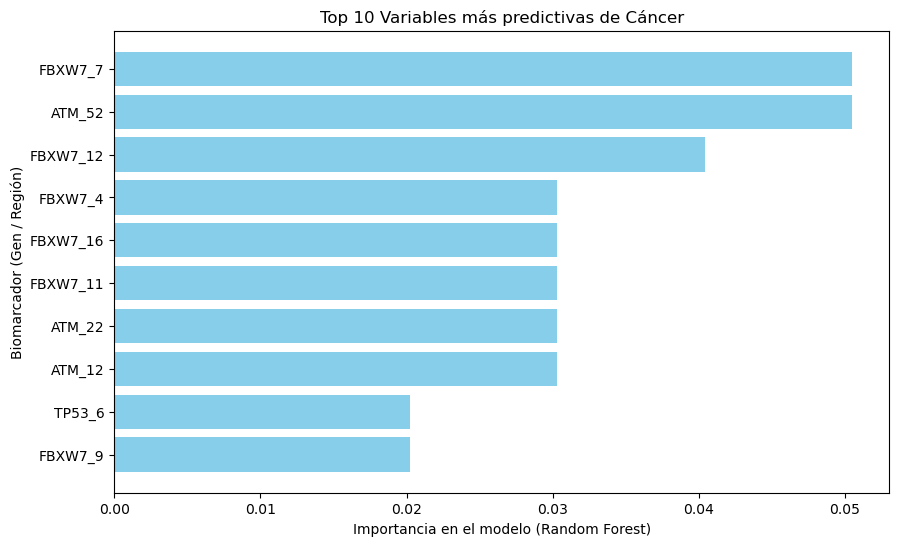

In [8]:
# ==========================================
# LATE FUSION Y EXTRACCIÓN DE BIOMARCADORES
# ==========================================
from scipy.stats import mode
import matplotlib.pyplot as plt

print("Ejecutando Fusión Tardía y extrayendo el Top 10 de Biomarcadores...")

# 1. Late Fusion
modelo_rna = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_epig = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_snv = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_cnv = RandomForestClassifier(n_estimators=100, random_state=42)

predicciones_late = []

for train_index, test_index in loo.split(y_target):
    y_train = y_target[train_index]
    
    modelo_rna.fit(df_rna_norm.values[train_index], y_train)
    modelo_epig.fit(df_epig_norm.values[train_index], y_train)
    modelo_snv.fit(df_snv_final.values[train_index], y_train)
    modelo_cnv.fit(df_cnv_final.values[train_index], y_train)
    
    votos = [
        modelo_rna.predict(df_rna_norm.values[test_index])[0],
        modelo_epig.predict(df_epig_norm.values[test_index])[0],
        modelo_snv.predict(df_snv_final.values[test_index])[0],
        modelo_cnv.predict(df_cnv_final.values[test_index])[0]
    ]
    predicciones_late.append(mode(votos, keepdims=False)[0])

accuracy_late = accuracy_score(y_target, predicciones_late)
print(f"Precisión (Accuracy) Late Fusion: {accuracy_late * 100:.2f}%\n")

# 2. Extracción de Biomarcadores (Top 10)
todas_las_caracteristicas = df_rna_norm.columns.tolist() + df_epig_norm.columns.tolist() + df_snv_final.columns.tolist() + df_cnv_final.columns.tolist()

modelo_final = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_final.fit(df_early_fusion.values, y_target)

importancias = modelo_final.feature_importances_
indices_ordenados = np.argsort(importancias)[::-1]

top_n = 10
top_caracteristicas = []
top_importancias = []

print(f"--- TOP {top_n} BIOMARCADORES MÁS IMPORTANTES ---")
for i in range(top_n):
    indice_actual = indices_ordenados[i]
    nombre_var = todas_las_caracteristicas[indice_actual]
    importancia_var = importancias[indice_actual]
    top_caracteristicas.append(nombre_var)
    top_importancias.append(importancia_var)
    print(f"{i+1}. {nombre_var}: {importancia_var:.4f}")

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(top_caracteristicas[::-1], top_importancias[::-1], color='skyblue')
plt.xlabel('Importancia en el modelo (Random Forest)')
plt.ylabel('Biomarcador (Gen / Región)')
plt.title('Top 10 Variables más predictivas de Cáncer')
plt.show()